In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

# 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add scripts folder to path
sys.path.append(os.path.abspath("../scripts"))

# Import our custom EDA functions
from eda_functions import *

# Settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# 2. Load dataset

In [13]:
# Load the data
df = load_data("../data/raw/german.csv", clean_cols=True, drop_unnamed=True)

# Preview
df.head()

,CheckingAccountStatus,Duration,CreditHistory,Purpose,CreditAmount,SavingsAccount,EmploymentSince,InstallmentRate,PersonalStatusSex,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,ExistingCredits,Job,Dependents,Telephone,ForeignWorker,Class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


# 3. Basic Overview

In [14]:
# Dataset shape
print("Dataset Shape:", df.shape)


Dataset Shape: (1000, 21)


In [15]:

# Data types & missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CheckingAccountStatus  1000 non-null   object
 1   Duration               1000 non-null   int64 
 2   CreditHistory          1000 non-null   object
 3   Purpose                1000 non-null   object
 4   CreditAmount           1000 non-null   int64 
 5   SavingsAccount         1000 non-null   object
 6   EmploymentSince        1000 non-null   object
 7   InstallmentRate        1000 non-null   int64 
 8   PersonalStatusSex      1000 non-null   object
 9   OtherDebtors           1000 non-null   object
 10  ResidenceSince         1000 non-null   int64 
 11  Property               1000 non-null   object
 12  Age                    1000 non-null   int64 
 13  OtherInstallmentPlans  1000 non-null   object
 14  Housing                1000 non-null   object
 15  ExistingCredits       

In [16]:

# Summary statistics
df.describe()


,Duration,CreditAmount,InstallmentRate,ResidenceSince,Age,ExistingCredits,Dependents,Class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [17]:
# Missing values (our function prints nicely)
missing_values_report(df)

No missing values.


Series([], dtype: int64)

# 4. Target Variable Processing

In [18]:
# Map target: 1=Good -> 0, 2=Bad -> 1
df = map_target(df, 'Class', {1: 0, 2: 1})

# Check distribution
df['Class'].value_counts()


Class
0    700
1    300
Name: count, dtype: int64

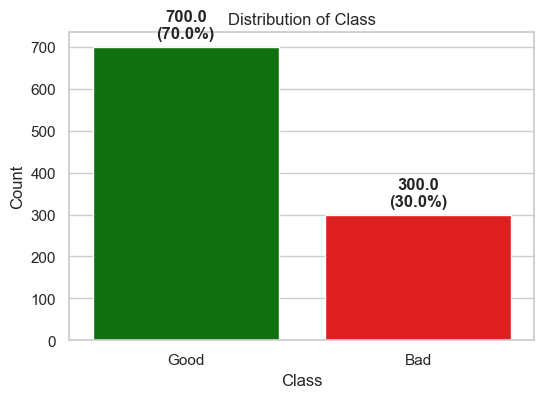

In [19]:
# Plot target distribution with labels
plot_target_distribution(df, 'Class',
                         labels=['Good', 'Bad'],
                         palette={0: 'green', 1: 'red'})

# 5. Separate Feature Types

In [20]:
# Automatically get numerical and categorical features (excluding target)
num_cols, cat_cols = get_feature_types(df, target='Class')

print("Numerical Features:", num_cols)
print("Categorical Features:", cat_cols)

Numerical Features: ['Duration', 'CreditAmount', 'InstallmentRate', 'ResidenceSince', 'Age', 'ExistingCredits', 'Dependents']
Categorical Features: ['CheckingAccountStatus', 'CreditHistory', 'Purpose', 'SavingsAccount', 'EmploymentSince', 'PersonalStatusSex', 'OtherDebtors', 'Property', 'OtherInstallmentPlans', 'Housing', 'Job', 'Telephone', 'ForeignWorker']


# 6. Numerical Feature Analysis
## Descriptive Statistics

In [21]:
range_df = df[num_cols].agg(['min', 'max']).T
range_df.columns = ['Min', 'Max']
range_dfrange_df = df[num_cols].agg(['min', 'max']).T
range_df.columns = ['Min', 'Max']
range_df

range_df['Range'] = range_df['Max'] - range_df['Min']
range_df

,Min,Max,Range
Duration,4,72,68
CreditAmount,250,18424,18174
InstallmentRate,1,4,3
ResidenceSince,1,4,3
Age,19,75,56
ExistingCredits,1,4,3
Dependents,1,2,1


In [22]:
# Descriptive statistics
df[num_cols].describe()

,Duration,CreditAmount,InstallmentRate,ResidenceSince,Age,ExistingCredits,Dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


## Histograms

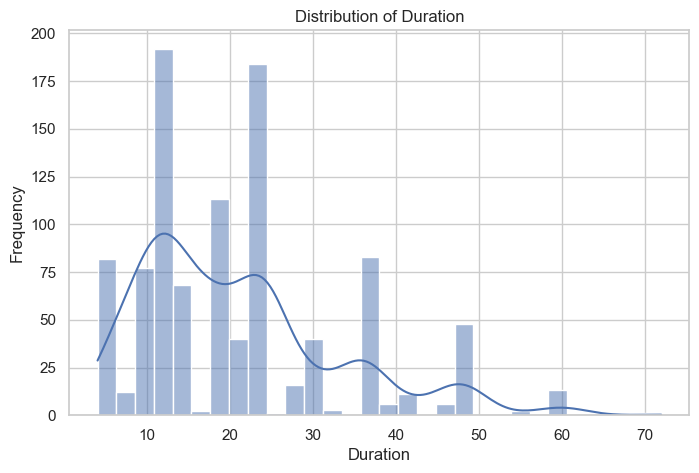

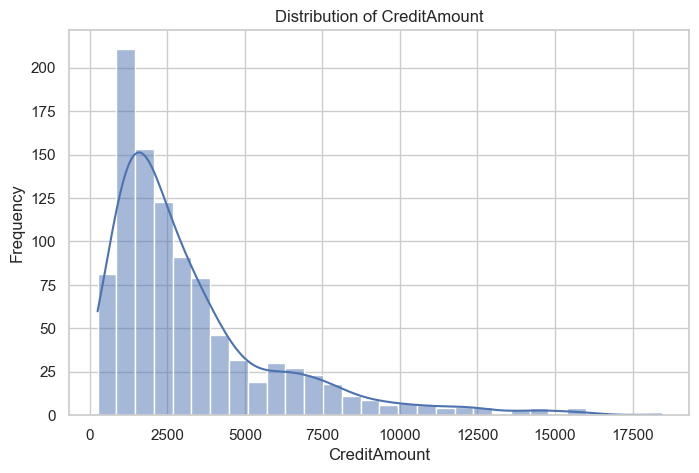

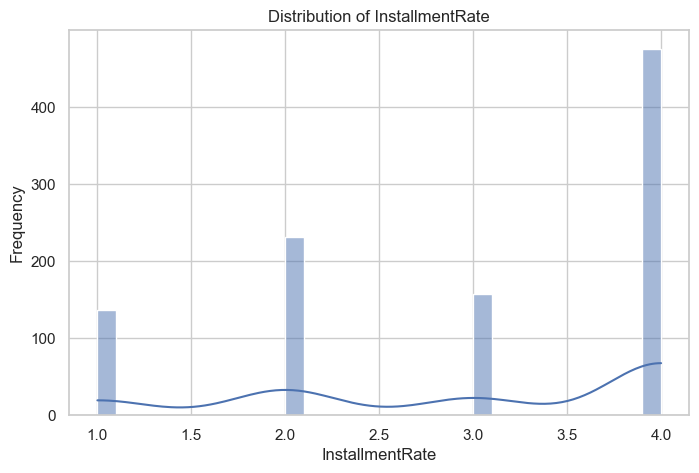

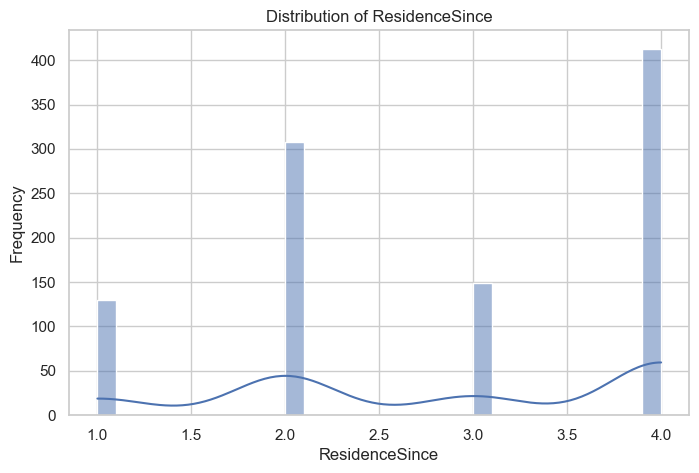

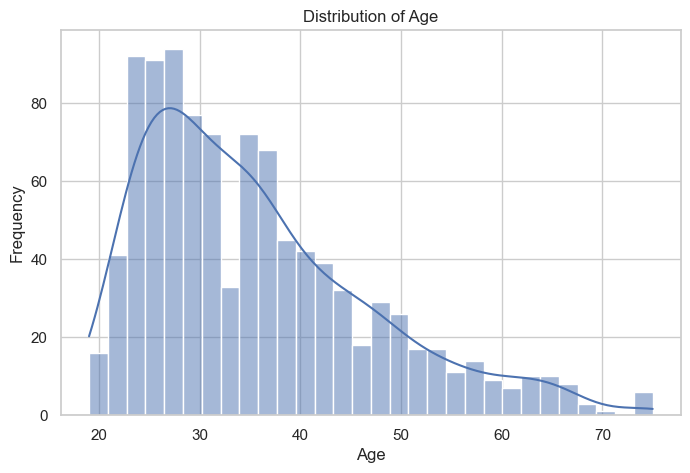

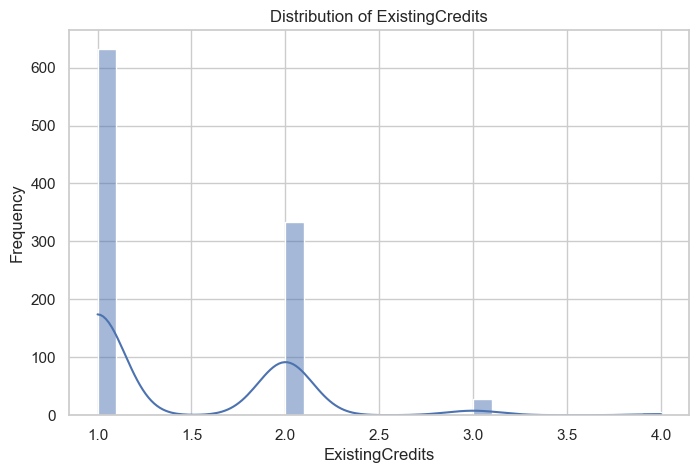

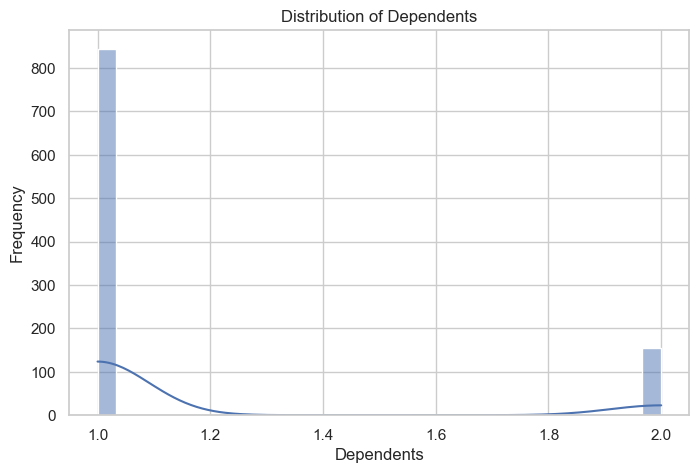

In [23]:
# Histograms with KDE
plot_numerical(df, cols=num_cols, kde=True)

## Boxplots (Outlier Detection)

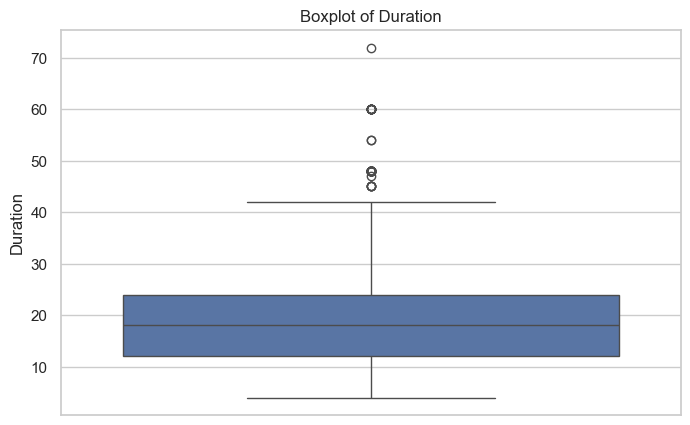

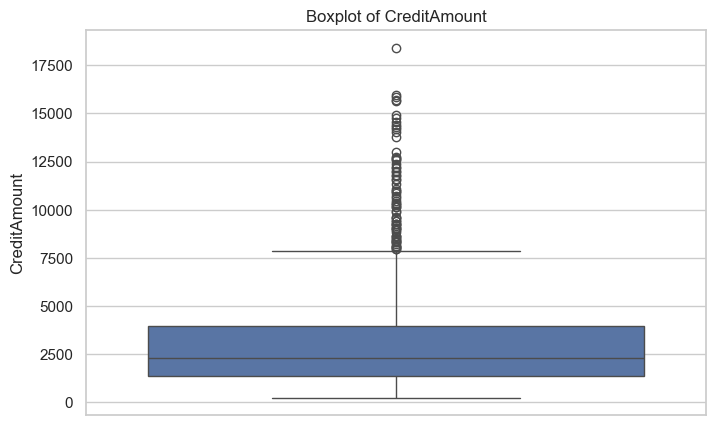

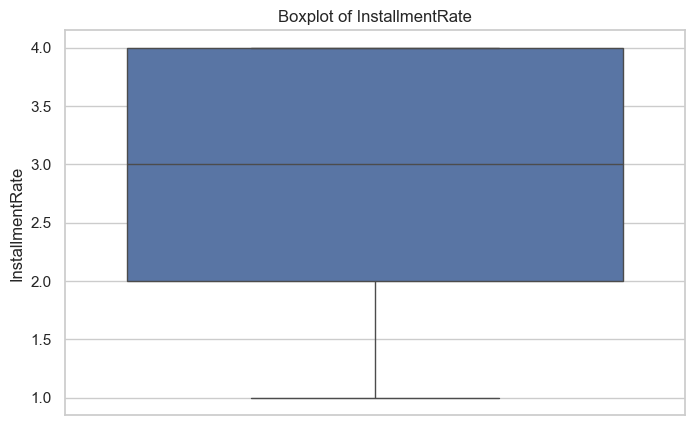

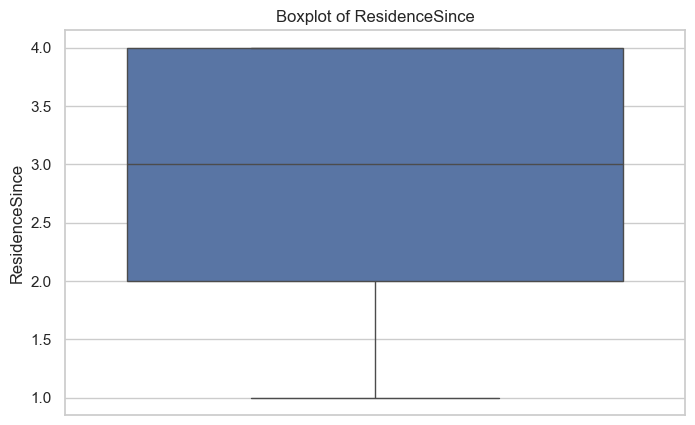

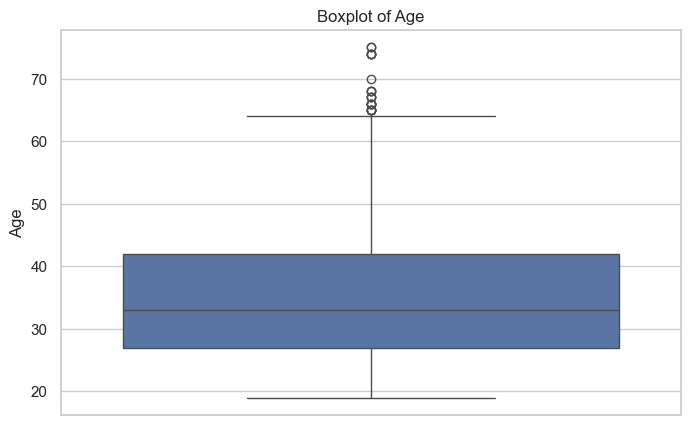

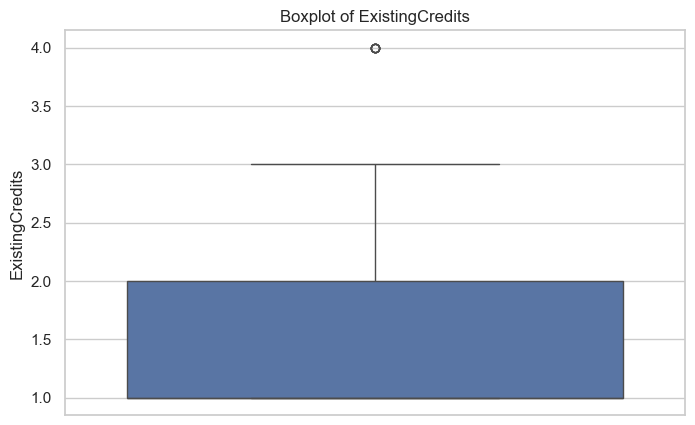

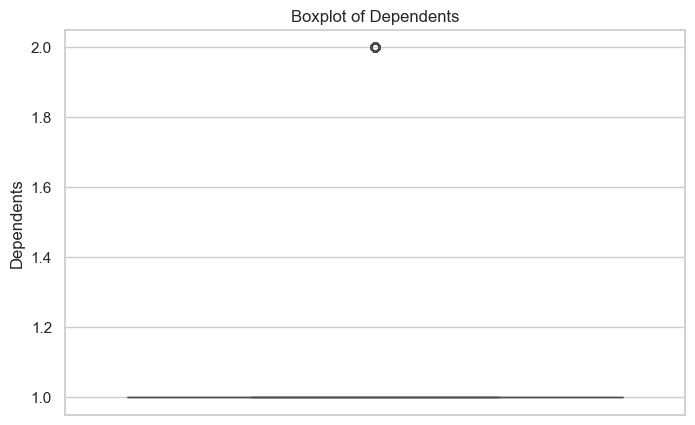

In [24]:
# Boxplots for outlier visualization
plot_outliers_boxplot(df, cols=num_cols)

# 7. Categorical Feature Analysis

## Value Counts

In [ ]:
# Value counts for each categorical feature
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


CheckingAccountStatus
CheckingAccountStatus
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64

CreditHistory
CreditHistory
A32    530
A34    293
A33     88
A31     49
A30     40
Name: count, dtype: int64

Purpose
Purpose
A43     280
A40     234
A42     181
A41     103
A49      97
A46      50
A45      22
A44      12
A410     12
A48       9
Name: count, dtype: int64

SavingsAccount
SavingsAccount
A61    603
A65    183
A62    103
A63     63
A64     48
Name: count, dtype: int64

EmploymentSince
EmploymentSince
A73    339
A75    253
A74    174
A72    172
A71     62
Name: count, dtype: int64

PersonalStatusSex
PersonalStatusSex
A93    548
A92    310
A94     92
A91     50
Name: count, dtype: int64

OtherDebtors
OtherDebtors
A101    907
A103     52
A102     41
Name: count, dtype: int64

Property
Property
A123    332
A121    282
A122    232
A124    154
Name: count, dtype: int64

OtherInstallmentPlans
OtherInstallmentPlans
A143    814
A141    139
A142     47
Name: count, dty

## Count Plots

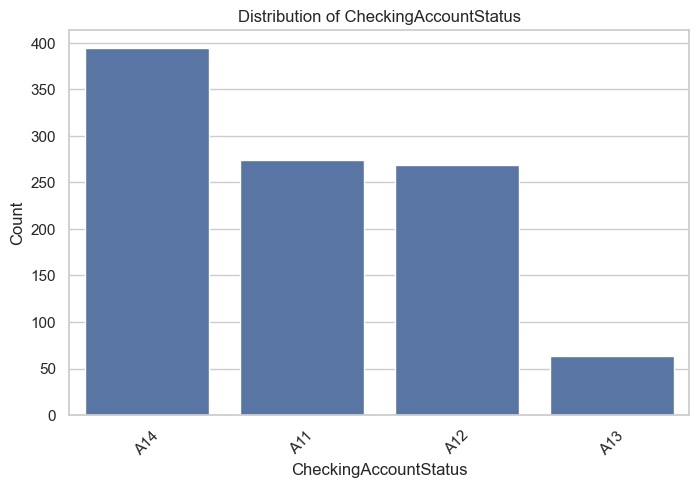

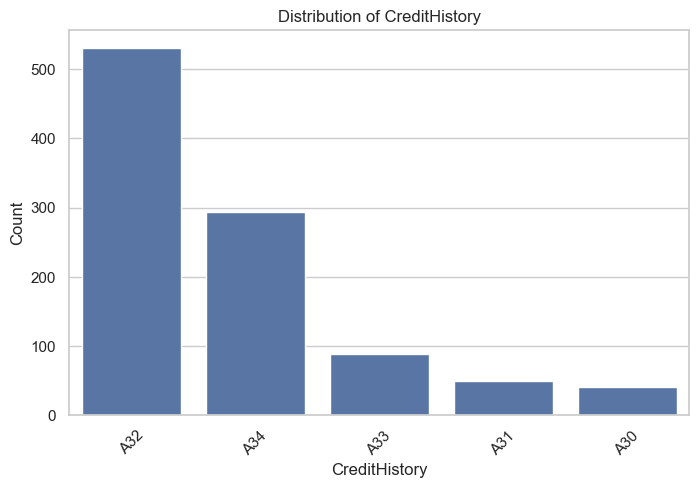

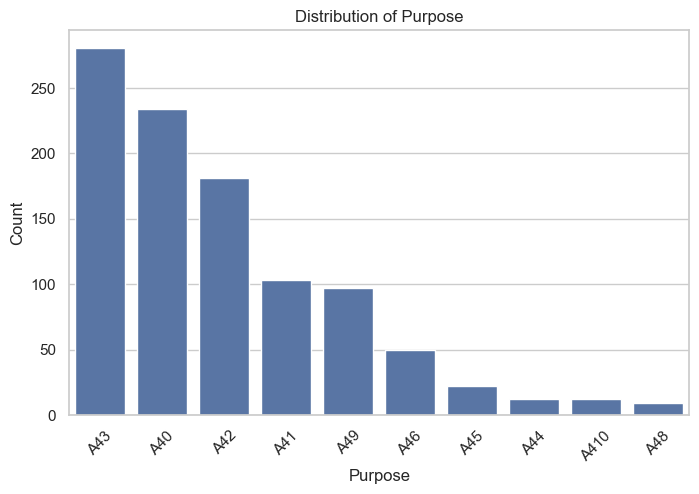

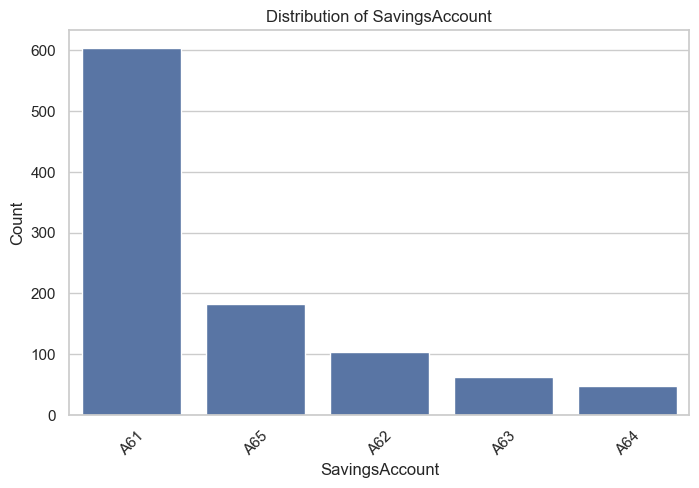

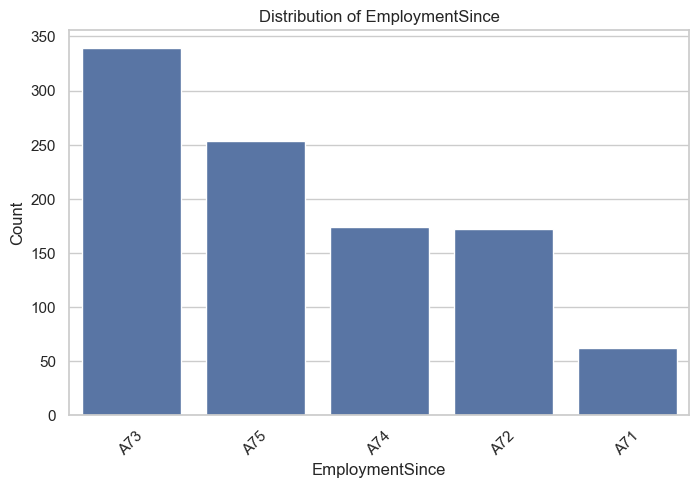

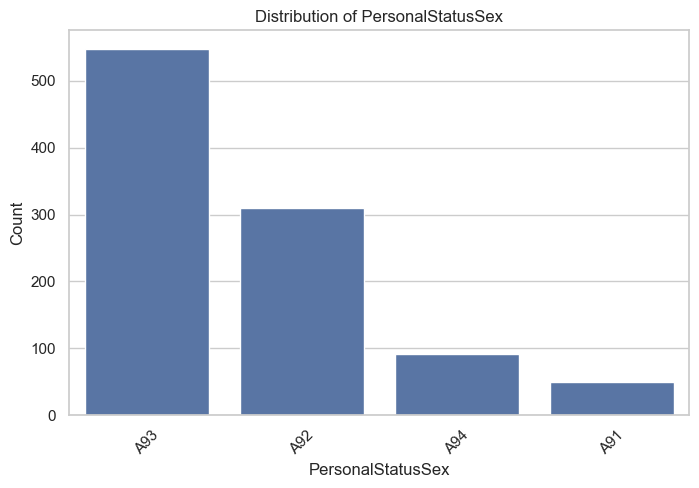

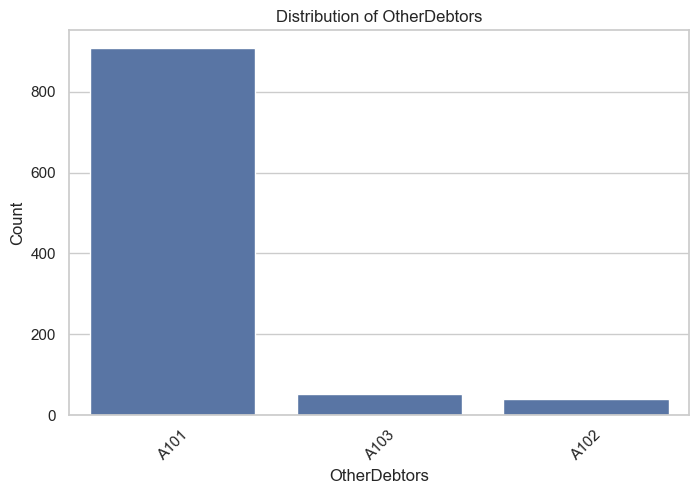

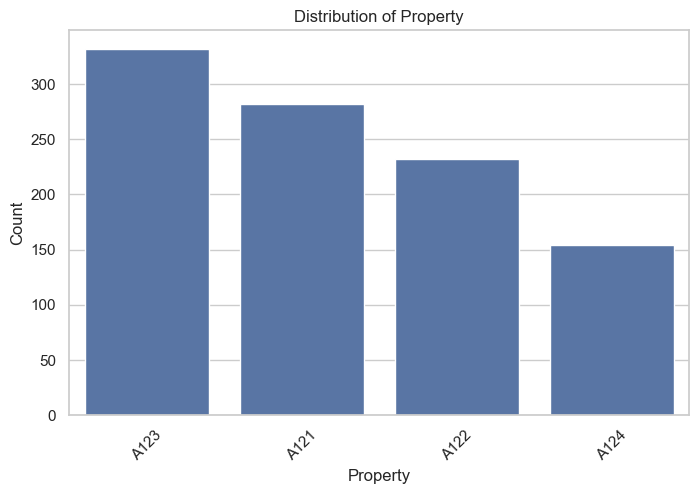

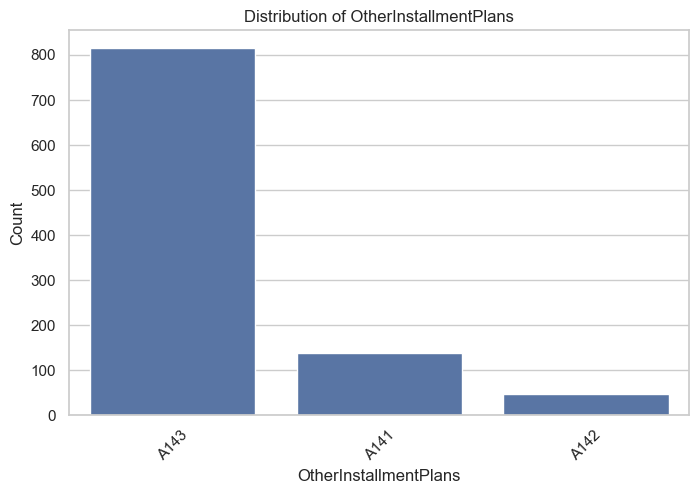

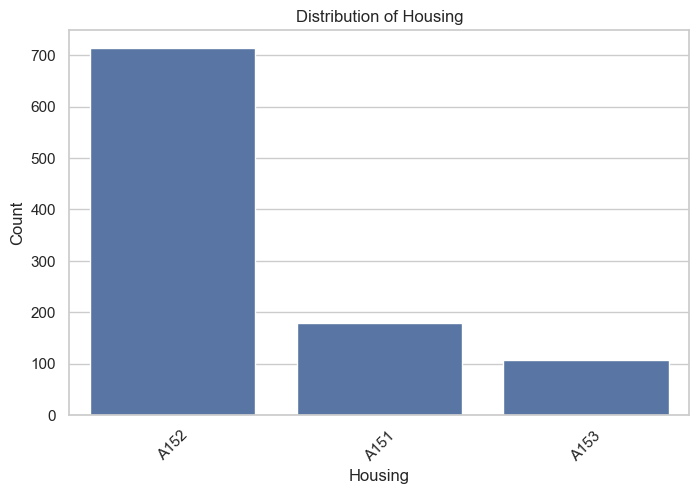

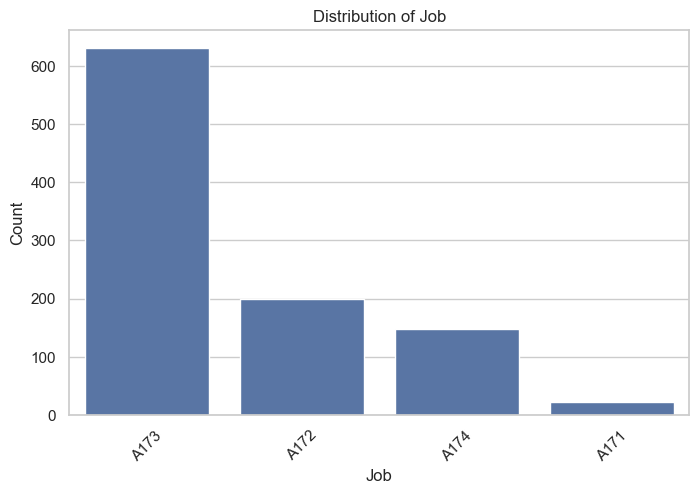

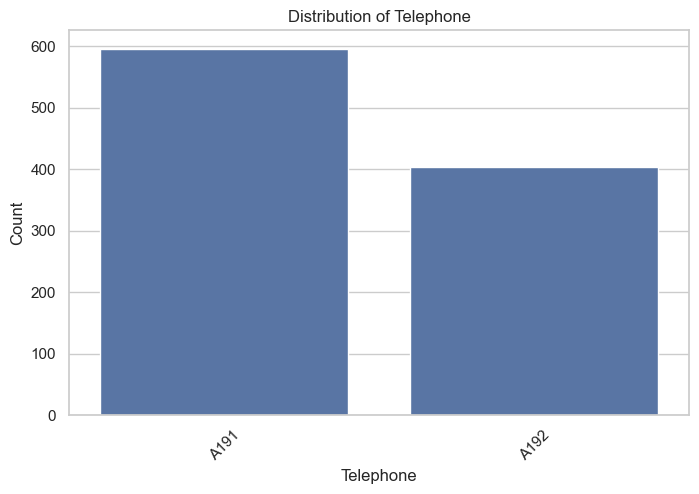

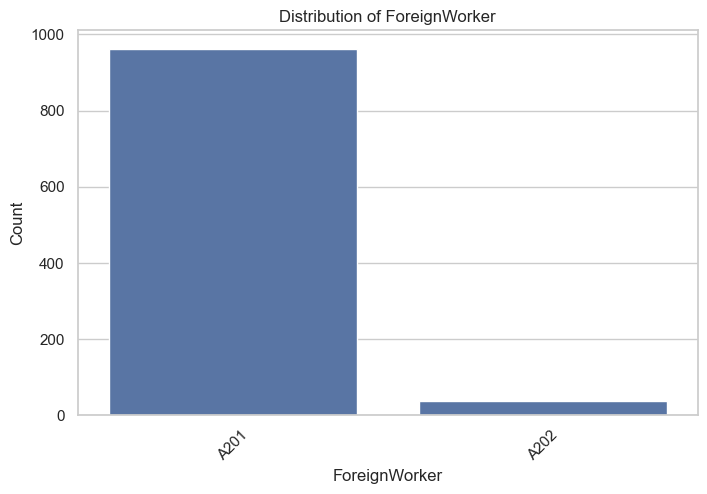

In [26]:
# Count plots (horizontal, top 10 categories if needed)
plot_categorical(df, cols=cat_cols, max_categories=10, horizontal=False)

# 8. Bivariate Analysis (Feature vs Target)

## Categorical vs Target

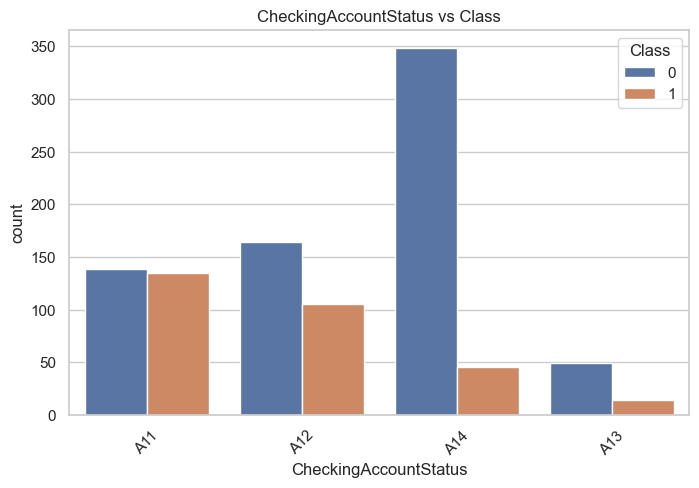

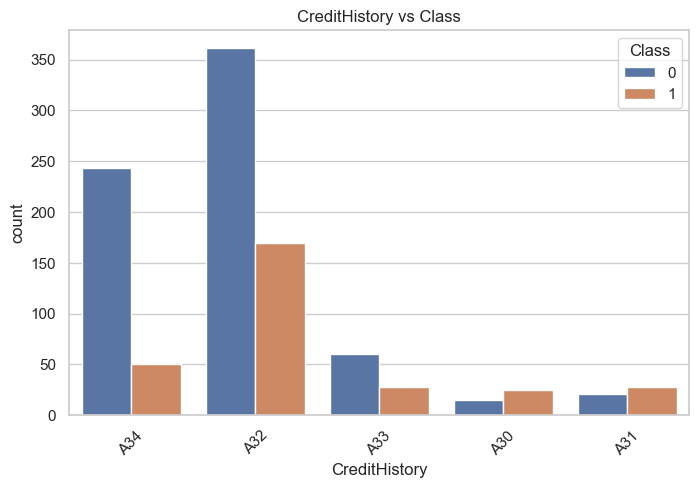

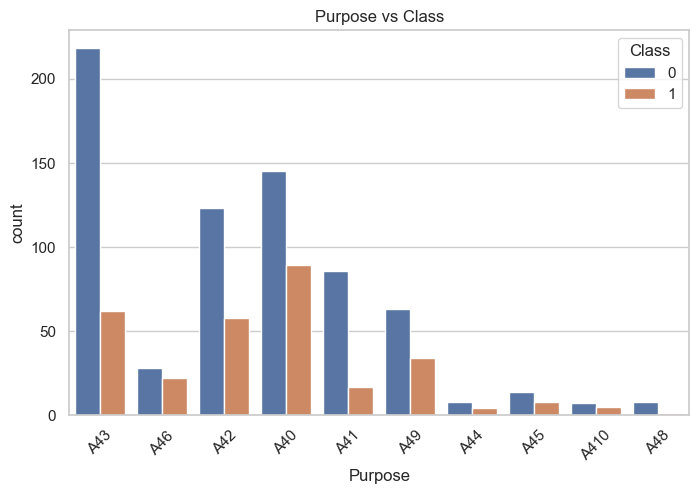

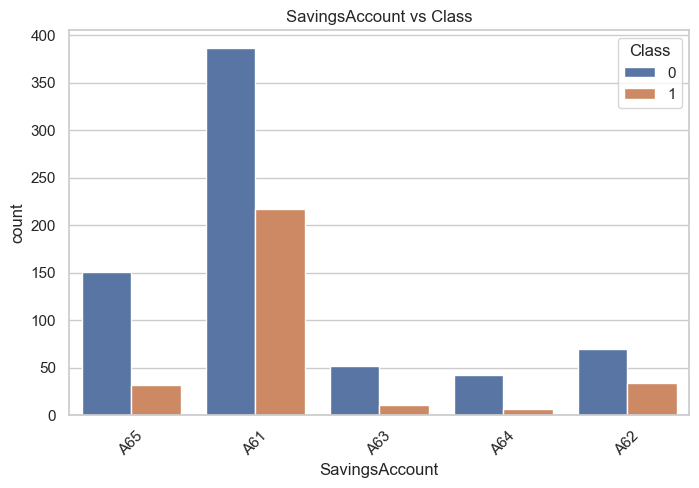

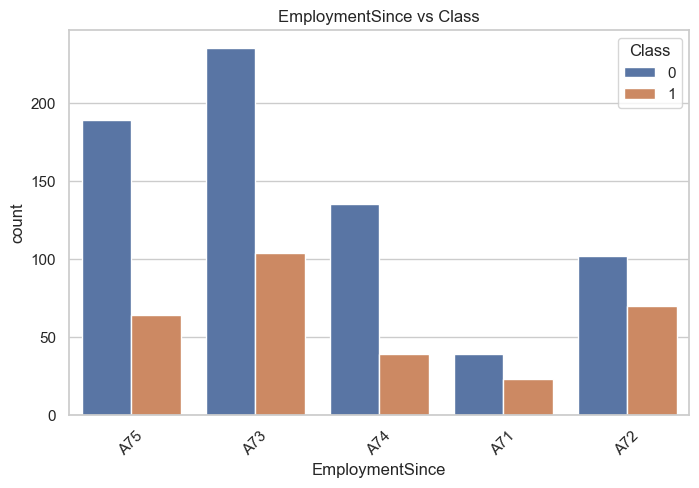

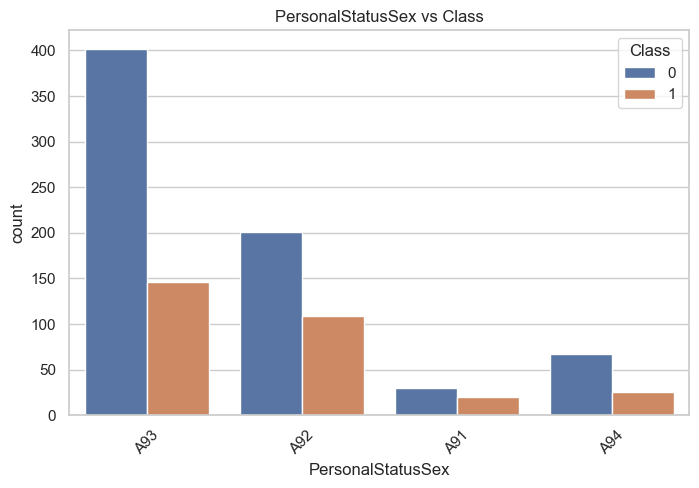

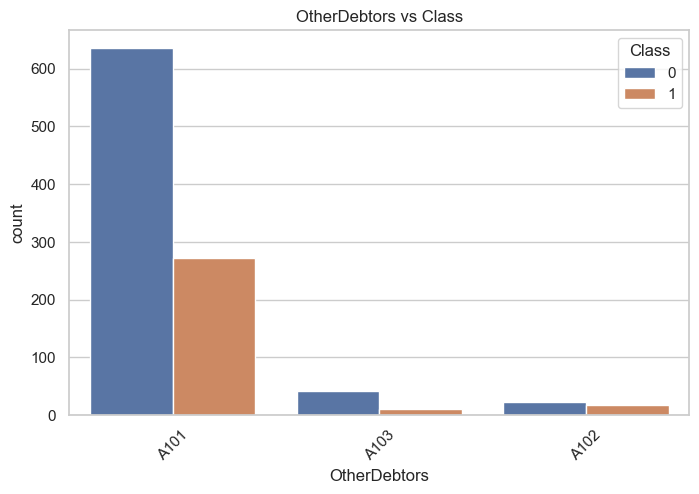

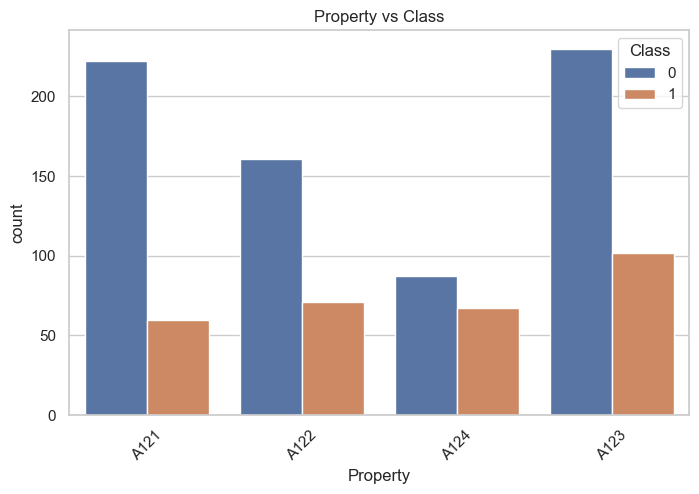

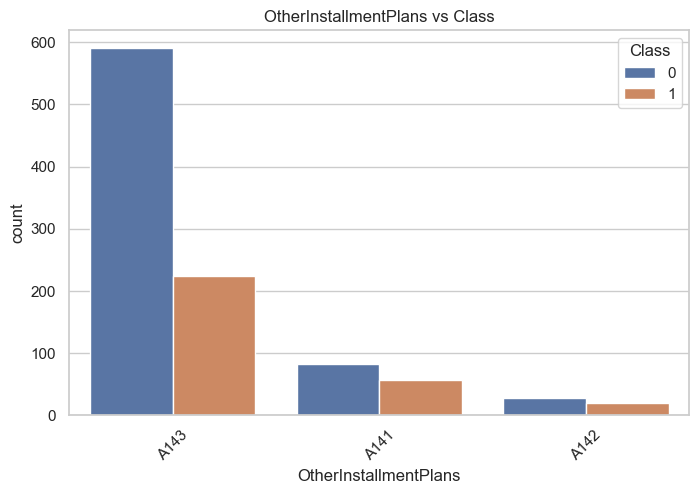

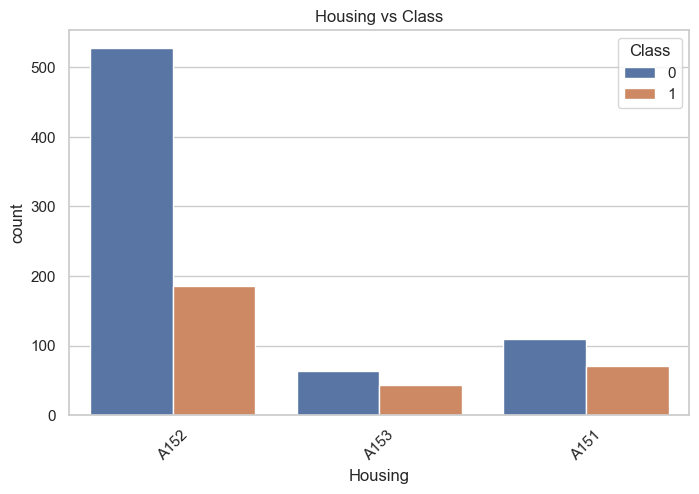

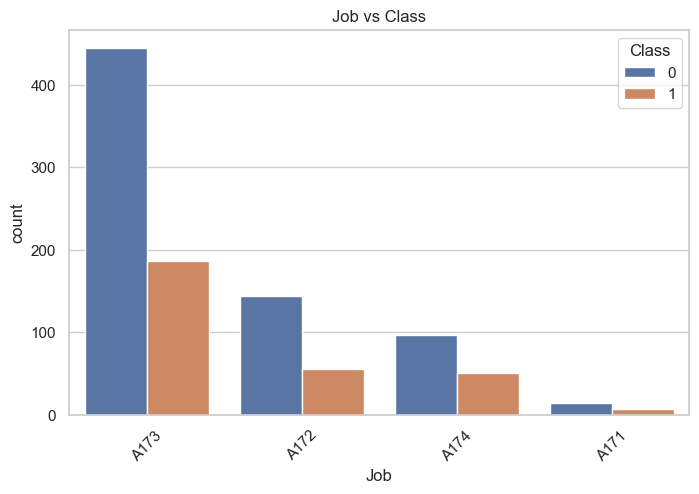

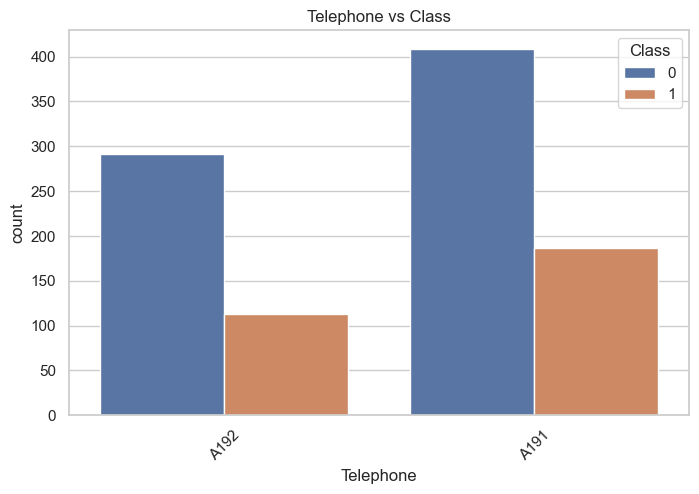

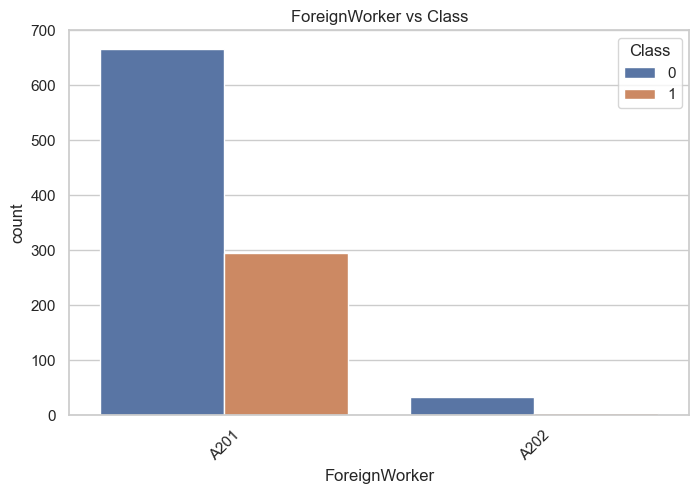

In [27]:
# Categorical vs target
plot_cat_vs_target(df, cat_cols, target='Class')

## Numerical vs Target

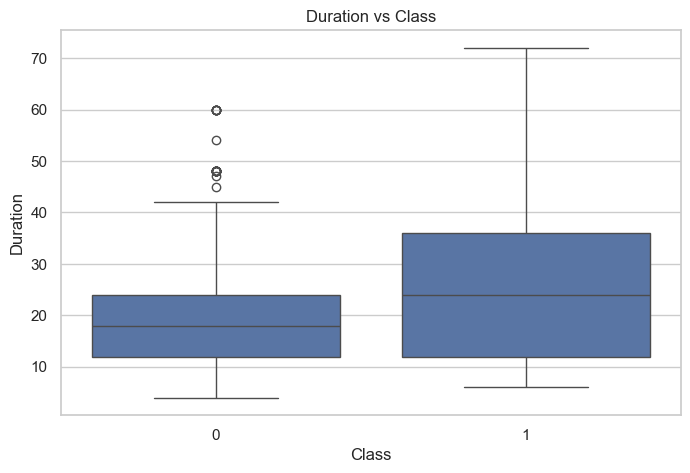

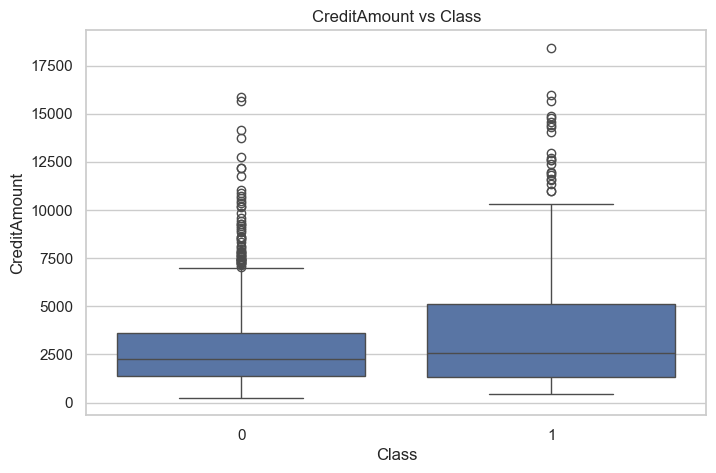

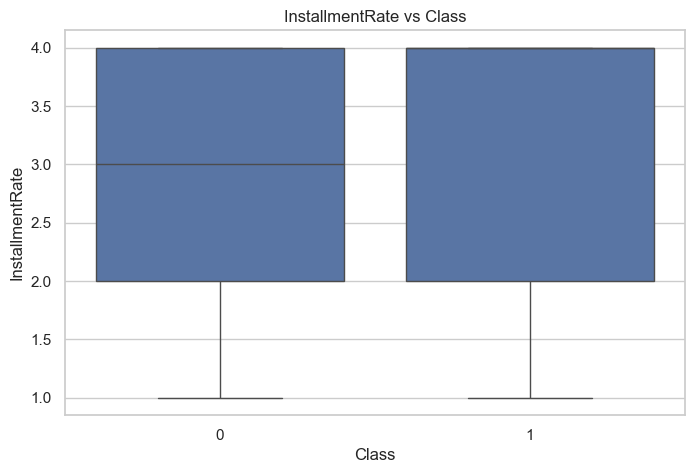

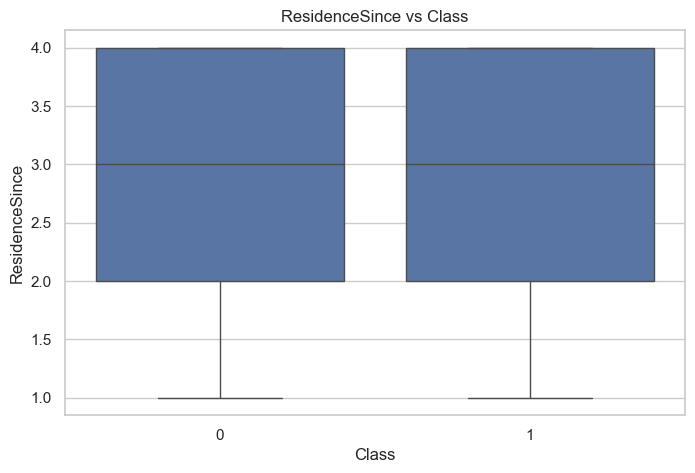

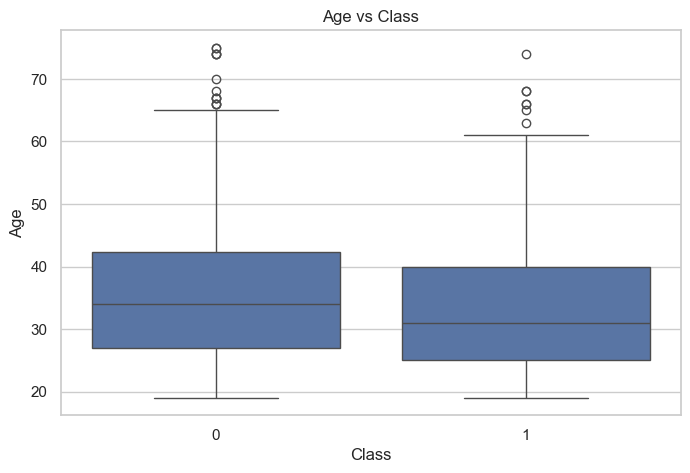

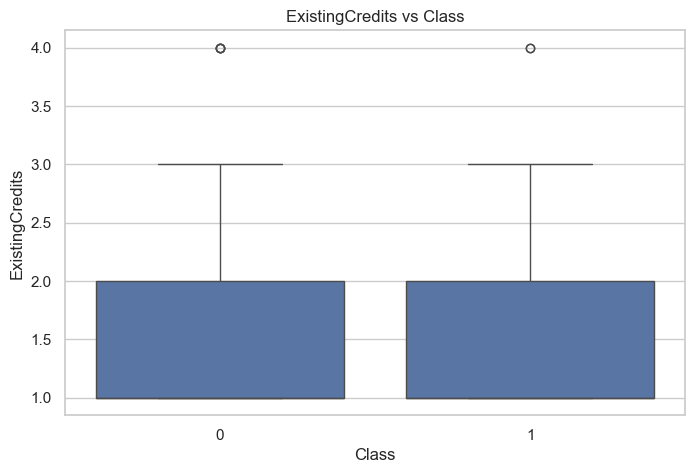

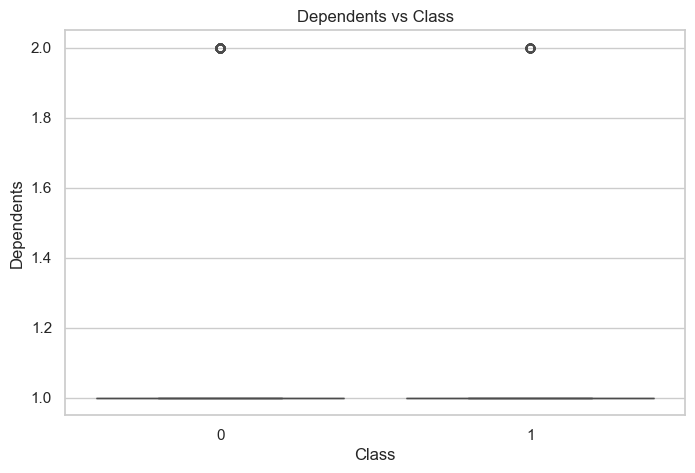

In [28]:
# Numerical vs target
plot_num_vs_target(df, num_cols, target='Class')

# 9. Correlation Analysis

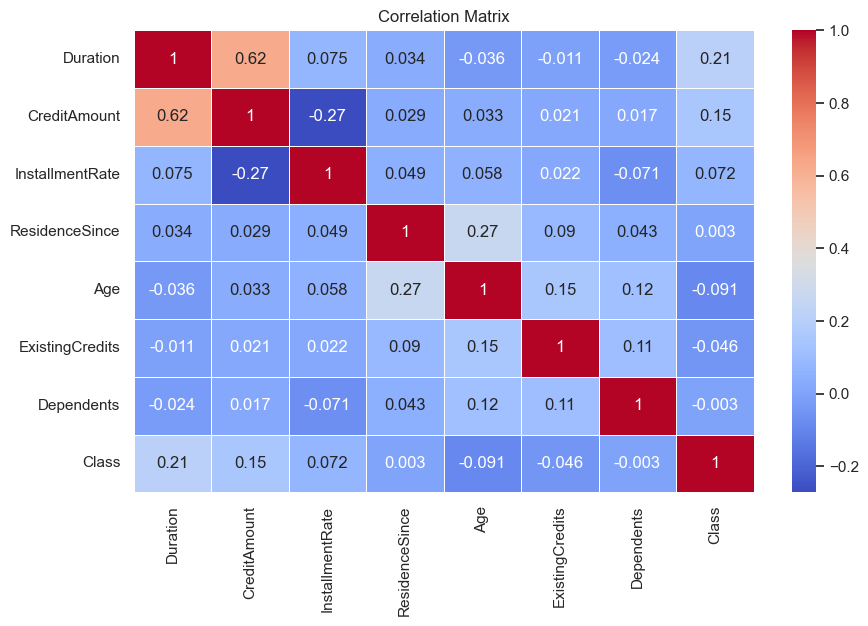

,Duration,CreditAmount,InstallmentRate,ResidenceSince,Age,ExistingCredits,Dependents,Class
Duration,1.000000,0.624984,0.074749,0.034067,-0.036136,-0.011284,-0.023834,0.214927
CreditAmount,0.624984,1.000000,-0.271316,0.028926,0.032716,0.020795,0.017142,0.154739
InstallmentRate,0.074749,-0.271316,1.000000,0.049302,0.058266,0.021669,-0.071207,0.072404
ResidenceSince,0.034067,0.028926,0.049302,1.000000,0.266419,0.089625,0.042643,0.002967
Age,-0.036136,0.032716,0.058266,0.266419,1.000000,0.149254,0.118201,-0.091127
ExistingCredits,-0.011284,0.020795,0.021669,0.089625,0.149254,1.000000,0.109667,-0.045732
Dependents,-0.023834,0.017142,-0.071207,0.042643,0.118201,0.109667,1.000000,-0.003015
Class,0.214927,0.154739,0.072404,0.002967,-0.091127,-0.045732,-0.003015,1.000000


In [20]:
# Correlation heatmap including target
all_num_cols = num_cols + ['Class']
correlation_heatmap(df, cols=all_num_cols, annot=True, cmap='coolwarm')

## 11. Outlier Detection (IQR Method Example)

In [21]:
# Print outlier counts for all numerical features
outlier_summary(df, cols=num_cols)

# (Optional) Examine outliers for a specific column
outliers_duration = detect_outliers_iqr(df, 'Duration')
print(f"Outliers in Duration: {len(outliers_duration)} rows")
outliers_duration.head()

Duration: 70 outliers
CreditAmount: 72 outliers
InstallmentRate: 0 outliers
ResidenceSince: 0 outliers
Age: 23 outliers
ExistingCredits: 6 outliers
Dependents: 155 outliers
Outliers in Duration: 70 rows


,CheckingAccountStatus,Duration,CreditHistory,Purpose,CreditAmount,SavingsAccount,EmploymentSince,InstallmentRate,PersonalStatusSex,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,ExistingCredits,Job,Dependents,Telephone,ForeignWorker,Class
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
11,A11,48,A32,A49,4308,A61,A72,3,A92,A101,...,A122,24,A143,A151,1,A173,1,A191,A201,1
29,A11,60,A33,A49,6836,A61,A75,3,A93,A101,...,A124,63,A143,A152,2,A173,1,A192,A201,1
35,A12,45,A34,A43,4746,A61,A72,4,A93,A101,...,A122,25,A143,A152,2,A172,1,A191,A201,1
36,A14,48,A34,A46,6110,A61,A73,1,A93,A101,...,A124,31,A141,A153,1,A173,1,A192,A201,0
